# **Setup OBLW — 01: Restart States**

## **0. Setup**

In [1]:
# Load packages
using Revise
using NeuralLongwave

In [2]:
# Build together raw data dir
RAW_DIR = raw_data_dir("OBLW", "01_setup", "01_restart_states")

# Select ICs
ICs = 1:5;

In [3]:
# Define plot scaling
scaled(k; kwargs...) = (; textwidth_cm = 15.0 * k,
                          fontsize     =  9   * k,
                          linewidth    =  1.2 * k,
                          markersize   =  7   * k,
                          kwargs...)

sc = scaled(1.8);

## **1. Evaluation**

In [4]:
# Calculate global means for each initial condition
ms = [global_means(RAW_DIR, ic) for ic in ICs];

┌ Warning: JSON-RPC endpoint has been blocked writing to its peer; outgoing messages are queueing up and will not be delivered until the peer resumes reading
│   blocked_seconds = 66.6
│   queued_messages = 0
└ @ VSCodeServer.JSONRPC c:\Users\stefa\.vscode\extensions\julialang.language-julia-1.242.2\scripts\packages\JSONRPC\src\core.jl:414


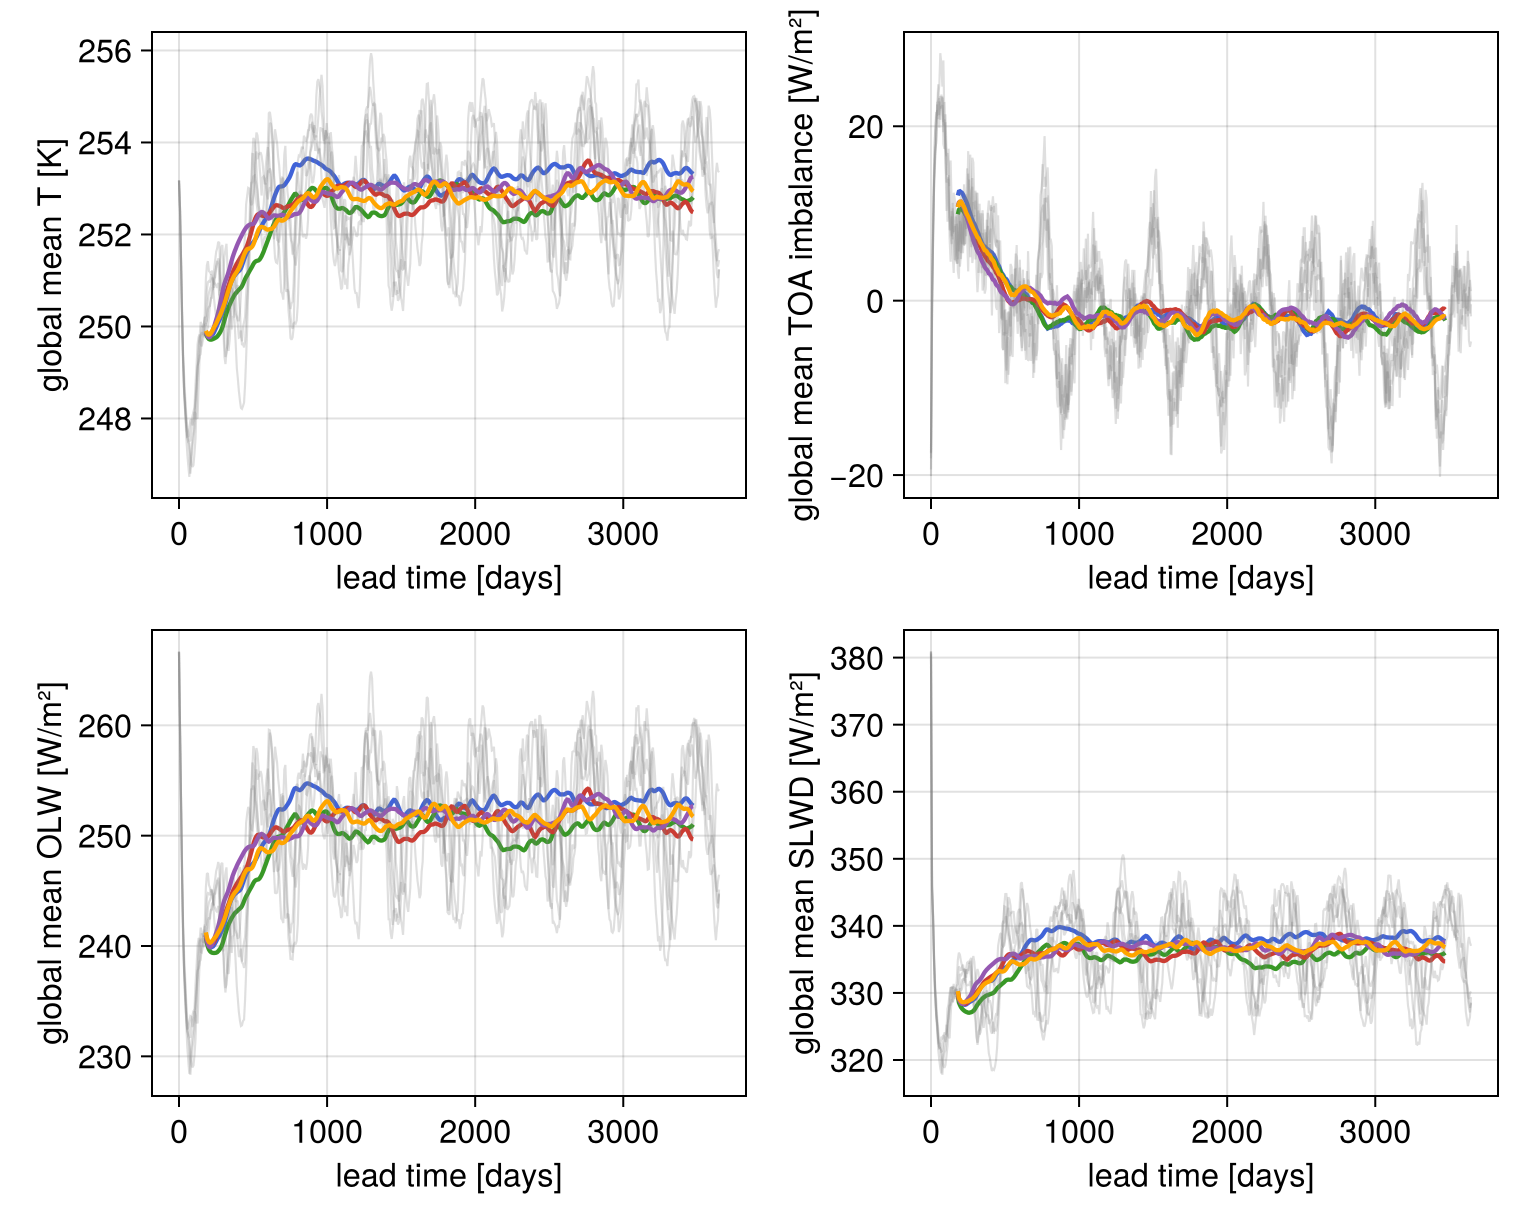

In [5]:
# Set plot parameters
smooth_days = 365

# Create plot
plot_probes(ms, (:T, :imb_TOA, :olw, :slwd); smooth_days, style=sc)

## **2. Restart States**

In [6]:
derive_restart_states(; 
    raw_dir     = RAW_DIR,
    scheme      = "OBLW",
    unit        = "default",
    ic_subset   = ICs,
    n_keep      = 13,
    stride      = 4,
)

┌ Info: Info file written to C:\Code\NeuralLongwave.jl\data\restart_states\OBLW\default\info.toml!
└ @ NeuralLongwave C:\Code\NeuralLongwave.jl\src\utils\io.jl:227
┌ Info: Restart states derived from C:\Code\NeuralLongwave.jl\data\raw_data\OBLW\01_setup\01_restart_states stored at C:\Code\NeuralLongwave.jl\data\restart_states\OBLW\default!
└ @ NeuralLongwave C:\Code\NeuralLongwave.jl\src\data\derive_restart_states.jl:47
